In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Step 1: Load the dataset
train_df = pd.read_csv('./../Dataset/train.csv')
test_df = pd.read_csv('./../Dataset/test.csv')

# Separate labels and features for training data
train_labels = train_df['label']
train_images = train_df.drop(columns=['label'])

# Step 2: Reshape the images
train_images_reshaped = train_images.values.reshape(-1, 28, 28).astype(np.float32)  # Reshape to (num_samples, 28, 28)

# Split train set further into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    train_images_reshaped, train_labels, test_size=0.2, random_state=42
)


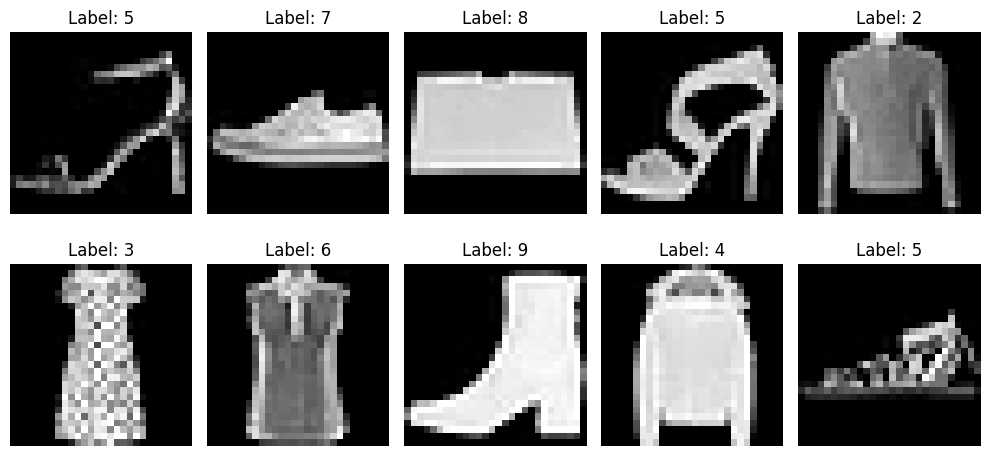

In [2]:
def visualize_samples(images, labels, num_samples=10):
    plt.figure(figsize=(10, 5))
    for i in range(num_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels.iloc[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize samples from the training data
visualize_samples(X_train, y_train)



Unique class labels: [2 9 6 0 3 4 5 8 7 1]


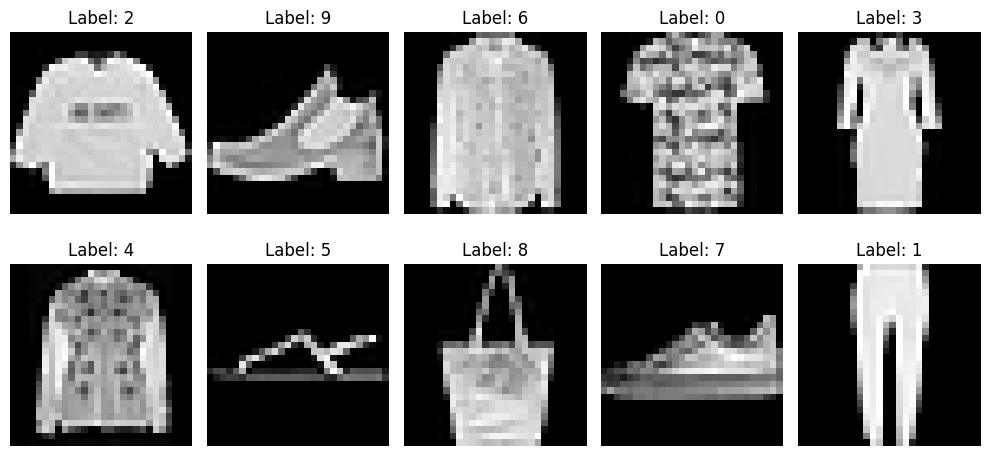

In [3]:

# Step 4: List the clothing types (class exploration)
unique_labels = train_labels.unique()
print("Unique class labels:", unique_labels)

# Visualize one example for each unique label in a 2x5 grid
def visualize_labels(images, labels, unique_labels):
    plt.figure(figsize=(10, 5))
    for i, label in enumerate(unique_labels):
        sample_image = images[labels == label][0]
        plt.subplot(2, 5, i + 1)
        plt.imshow(sample_image, cmap='gray')
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize one image per unique label
visualize_labels(train_images_reshaped, train_labels, unique_labels)



### Class Labels and Categories

| Label | Category       |
|-------|----------------|
| 0     | T-shirt/top    |
| 1     | Trouser        |
| 2     | Pullover       |
| 3     | Dress          |
| 4     | Coat           |
| 5     | Sandal         |
| 6     | Shirt          |
| 7     | Sneaker        |
| 8     | Bag            |
| 9     | Ankle boot     |


### 4.2 Model Implementation and Training

### 4.3 Plots and Performance Visualizations

### Trying out 3 variants for each of the models 

#### Model 1
1. [raw_features1.ipynb](raw_features1.ipynb)  
2. [raw_features2.ipynb](raw_features2.ipynb)  
3. [raw_features3.ipynb](raw_features3.ipynb)  

#### Model 2
1. [edge_detection1.ipynb](edge_detection1.ipynb)  
2. [edge_detection2.ipynb](edge_detection2.ipynb)  
3. [edge_detection3.ipynb](edge_detection3.ipynb)  

#### Model 3
1. [hog_features1.ipynb](hog_features1.ipynb)  
2. [hog_features2.ipynb](hog_features2.ipynb)  
3. [hog_features3.ipynb](hog_features3.ipynb)  


# Model Comparison and Performance Evaluation

## Best Models and Their Performance

### 1. **Raw Features 1**  
- **Accuracy:** 0.8799  
- **Plots:**
  - **Loss and Accuracy vs. Epoch:**
    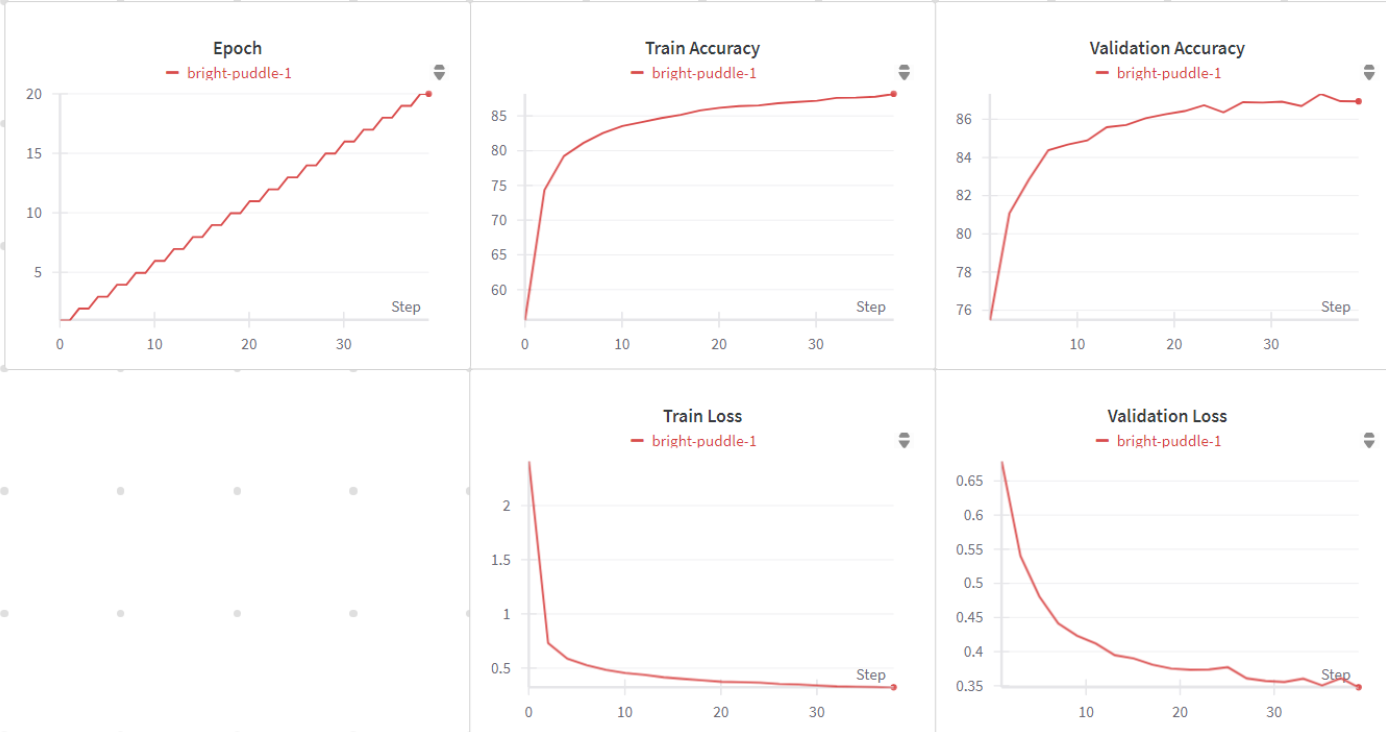
  - **Confusion Matrix:**
    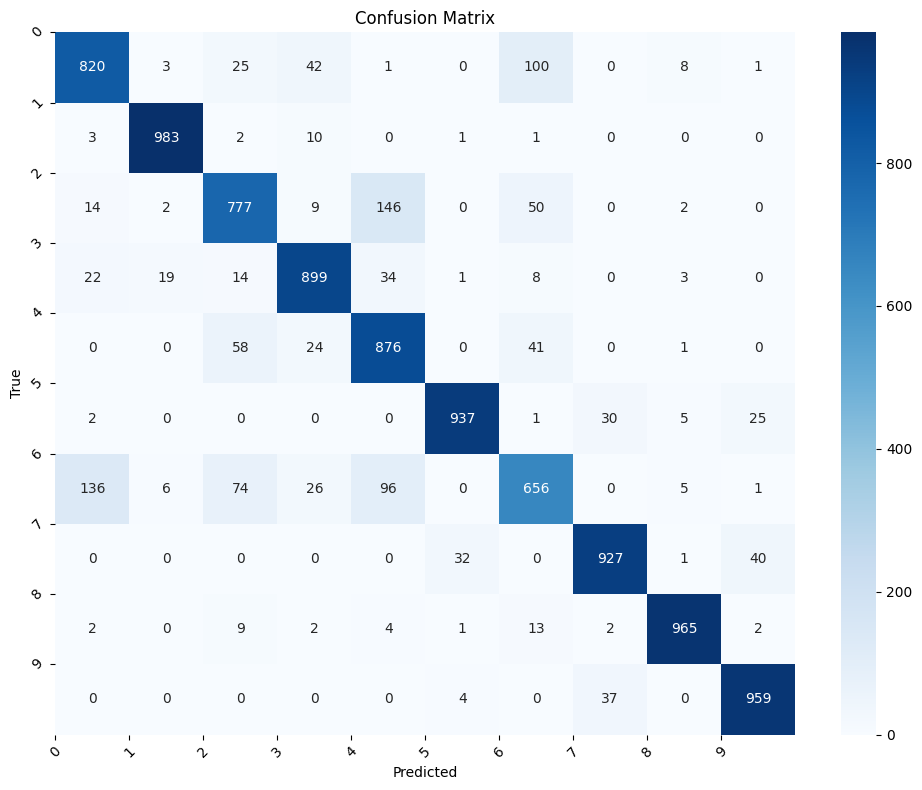

---

### 2. **Edge Detection 1**  
- **Accuracy:** 0.8518  
- **Plots:**
  - **Loss and Accuracy vs. Epoch:**
    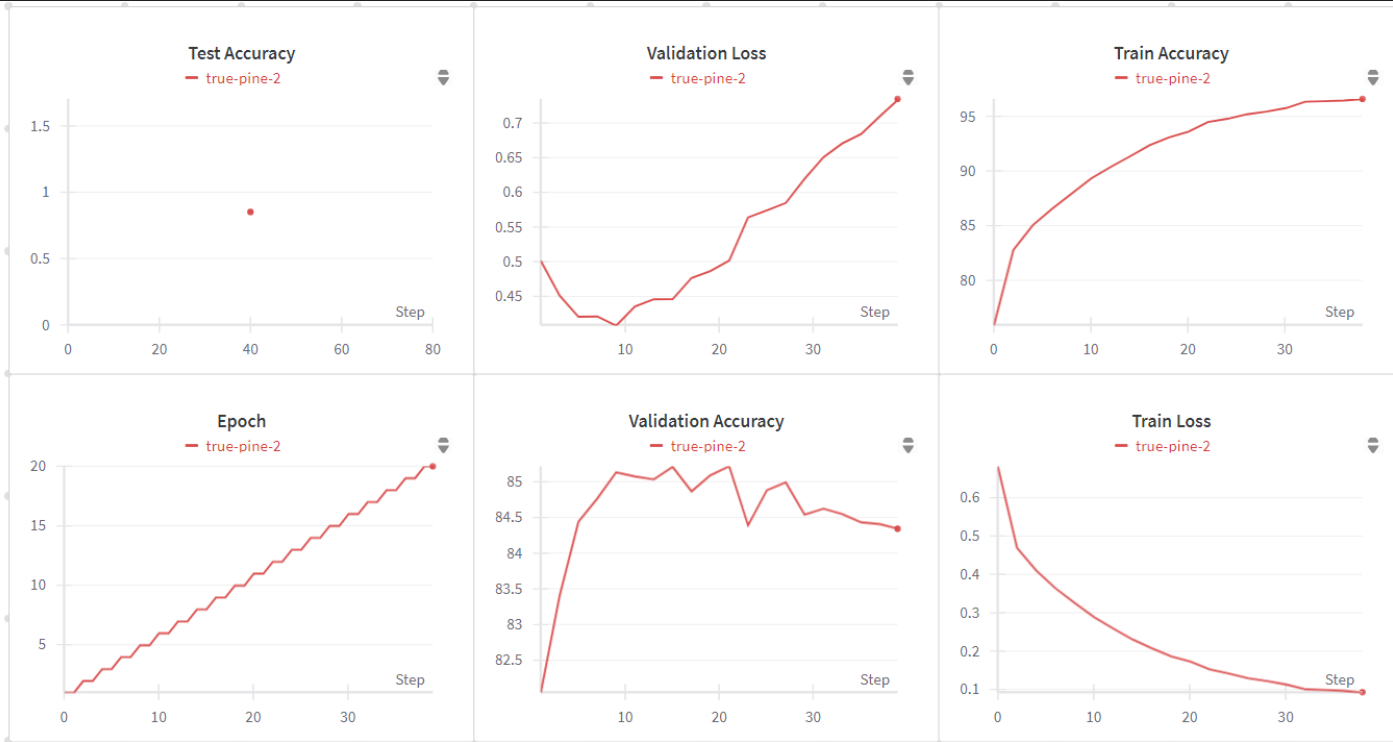
  - **Confusion Matrix:**
    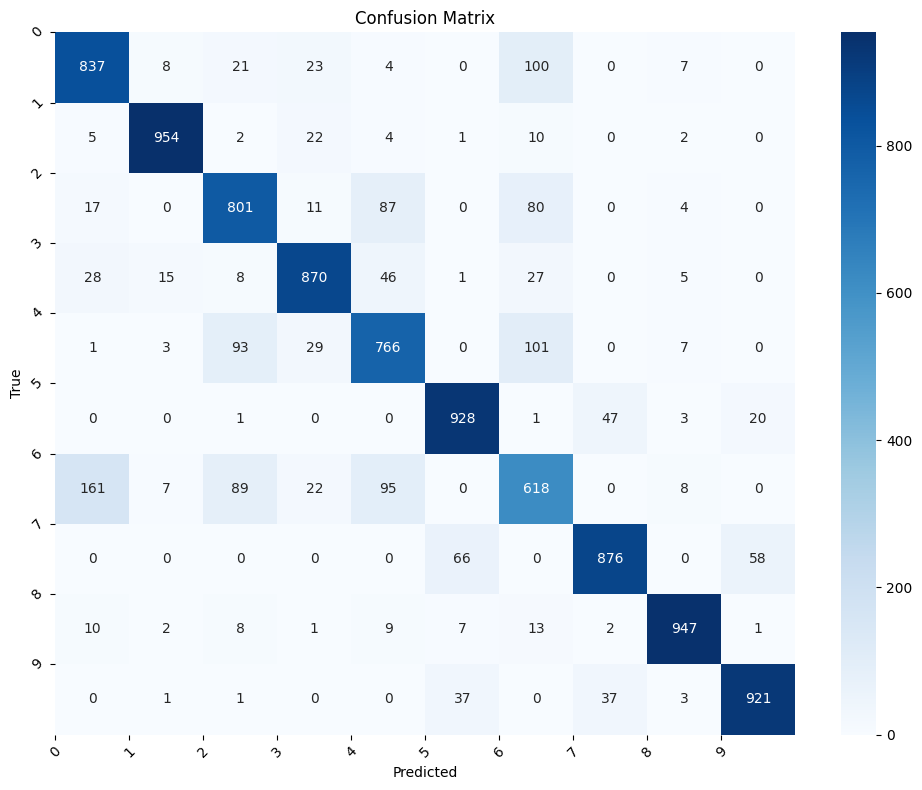

---

### 3. **HOG Features 2**  
- **Accuracy:** 0.9061  
- **Plots:**
  - **Loss and Accuracy vs. Epoch:**
    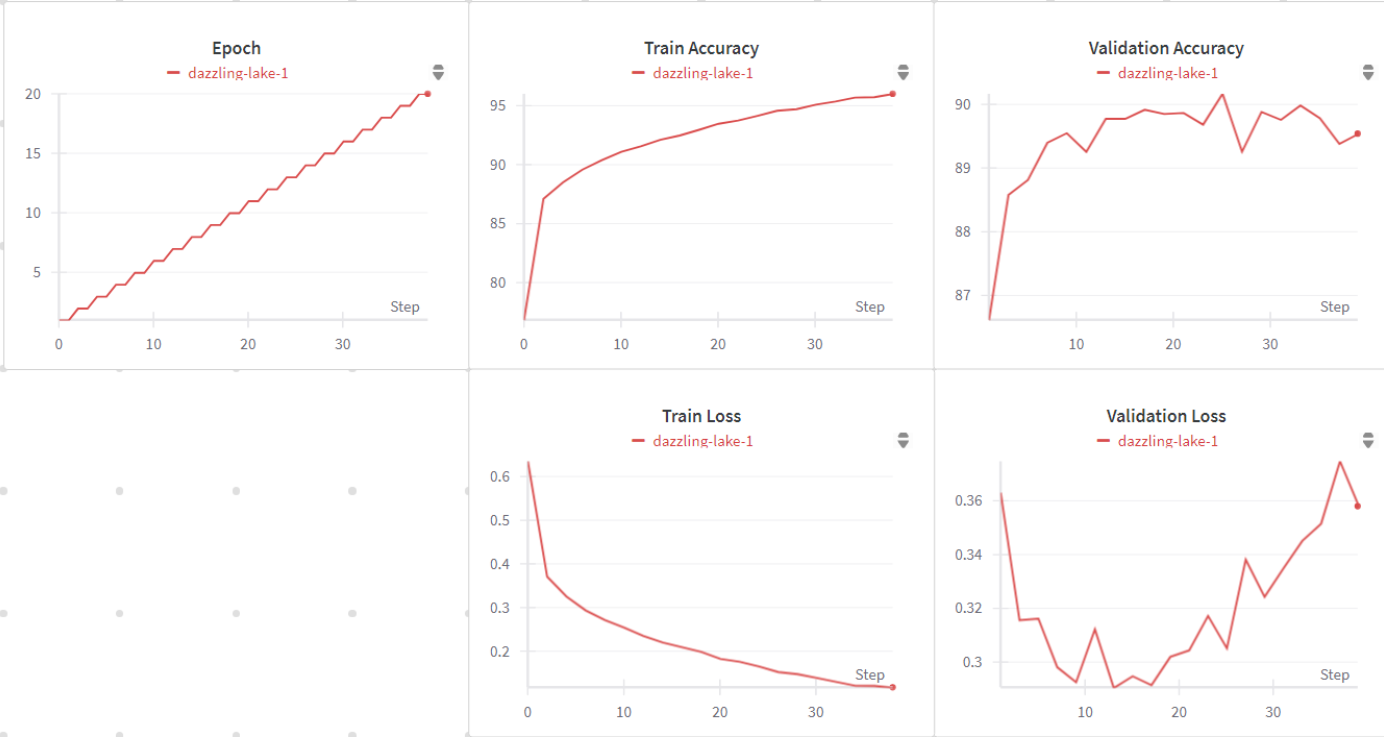
  - **Confusion Matrix:**
    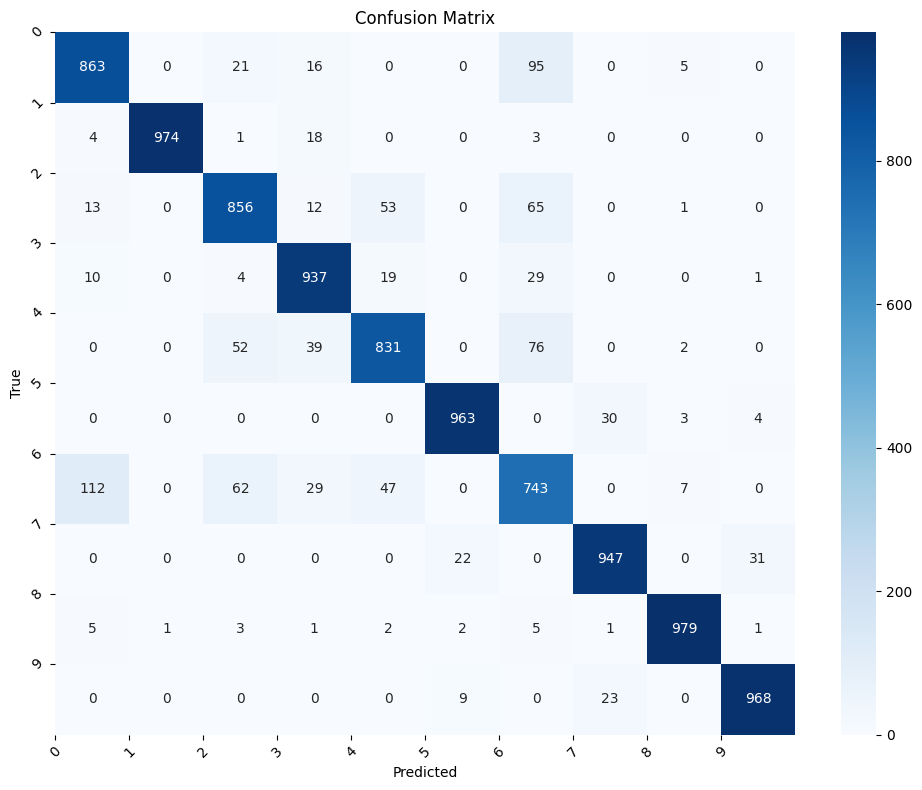

---


## 2) Analysis of Training and Validation Curves

### Model 1 (Raw Features):
- Training accuracy steadily increases and plateaus around 85-87%, while validation accuracy reaches about 85-86%.
- Training loss decreases rapidly in the first 10 epochs and then gradually stabilizes.
- Shows stable learning without significant overfitting, as validation and training curves remain relatively close.
- Quick initial learning but modest final performance.

### Model 2 (Edge Detection Features):
- Training accuracy reaches higher levels (~95%) compared to Model 1.
- Validation accuracy is unstable, fluctuating between 83-85%.
- Validation loss shows concerning behavior - it initially decreases but then starts increasing after epoch 20.
- Clear signs of overfitting as training accuracy continues improving while validation metrics worsen.

### Model 3 (HOG Features):
- Training accuracy reaches ~95%, similar to Model 2.
- Validation accuracy shows high variance, fluctuating between 88-90%.
- Training loss decreases smoothly, but validation loss shows an upward trend in later epochs.
- Better overall performance than Model 1, but also shows signs of overfitting.

### Key Observations:
- Model 1 (Raw Features) shows the most stable learning curve but achieves lower overall accuracy. This suggests that raw pixel values provide a consistent but perhaps less informative feature set.
- Model 2 (Edge Detection) achieves higher training accuracy but shows clear signs of overfitting, with diverging training and validation metrics. The edge features might be too specific to the training data.
- Model 3 (HOG Features) achieves the best validation accuracy among all models (~90%) but still shows some overfitting. HOG features seem to capture more relevant information for classification compared to raw pixels or edge detection.



## 3) Confusion Matrix Observations

### Model 1 (Raw Features)
- **Strong diagonal elements** indicating good overall performance.
- **Notable confusion** between classes 2 and 4 (146 misclassifications).
- Class 6 shows **significant confusion** with class 0 (136 cases).
- **Weakest performance** on class 6 (656 correct vs other classes >800).

### Model 2 (Edge Detection)
- **Similar patterns** to Model 1 but with increased confusion.
- **Lower accuracy** in class 4 (766 correct vs 876 in Model 1).
- **Higher confusion** between classes 7 and 9 (58 misclassifications).
- **Class 6 performance** degraded further (618 correct).

### Model 3 (HOG Features)
- **Best overall performance** with stronger diagonal elements.
- **Improved class 6 performance** (743 correct).
- **Reduced confusion** between classes 2 and 4.
- **More consistent performance** across all classes.
- Minor confusion remains between classes 7 and 9 (31 cases).

## Key Findings
- **HOG features (Model 3)** show the best overall classification performance.
- **Edge detection (Model 2)** unexpectedly performed worse than raw features.
- All models **struggle with class 6**, suggesting inherent difficulty in distinguishing this clothing type.
- **Classes 2/4 and 7/9** show consistent confusion across all models, indicating similar visual characteristics.

# 4) Performance Metrics and Analysis

## Performance Metrics Table

| Model Type               | Accuracy | Precision | Recall  | F1-Score |
|--------------------------|----------|-----------|---------|----------|
| Raw Features (Model 1)   | 0.8799   | 0.8799    | 0.8799  | 0.8791   |
| Edge Detection (Model 2) | 0.8518   | 0.8518    | 0.8519  | 0.8516   |
| HOG Features (Model 3)   | 0.9061   | 0.9066    | 0.9061  | 0.9062   |

## Analysis of Feature Influence
- **HOG features** produced the best results across all metrics, likely due to their ability to effectively capture shape and gradient information, which is crucial for distinguishing visual patterns in the dataset.
- **Edge detection** unexpectedly decreased performance by ~3% compared to raw features. This suggests that edge detection may have caused a loss of important texture and finer details necessary for accurate classification.
- **Raw features** performed surprisingly well, demonstrating robust baseline performance for this dataset, likely due to preserving all original information.
- Consistent metrics within each model indicate **balanced class performance**, with no single metric significantly diverging from the others.


# 4.4

# Performance Differences

- **HOG features** performed best (90.6% accuracy) by capturing shape/gradient information critical for clothing classification.  
- **Raw features** achieved 88% accuracy, showing the robustness of pixel-level information.  
- **Edge detection** underperformed (85.2% accuracy) due to the loss of texture details.  
- **HOG** showed better generalization with consistent performance across classes.  
- All models struggled with similar class pairs (2/4, 7/9), suggesting inherent visual similarities.

---

# Feature Extraction Impact & Scenarios

### HOG Features
- **Best for:** Complex shapes, consistent lighting, detailed textures.  
- **Advantages:** Captures gradient orientations, resistant to lighting changes.  
- **Use when:** Shape discrimination is crucial, and the dataset has varied lighting.

### Raw Features
- **Best for:** Large datasets, simple patterns, color-dependent classification.  
- **Advantages:** Preserves all information, works well with sufficient data.  
- **Use when:** Computing resources are abundant, and the dataset is well-preprocessed.

### Edge Detection
- **Best for:** Simple shape-based classification, high-contrast images.  
- **Advantages:** Reduces noise, highlights boundaries.  
- **Use when:** Boundaries are the primary discriminating factor, and background noise is present.
